In [15]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, accuracy_score
from sklearn.datasets import load_breast_cancer
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Load the dataset
data = load_breast_cancer(as_frame=True)
df = data.frame

# Step 1: Exploring the dataset
# Display the first 5 rows
print(df.head())
# Print the shape of the dataset
print(df.shape)
# Print the number of missing values in each column
print(df.isnull().sum())
# Print summary statistics
print(df.describe())
# Print the target class counts
print("\nTarget Class Counts:")
print(df['target'].value_counts())

   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst texture  worst perimeter  worst area  \
0             

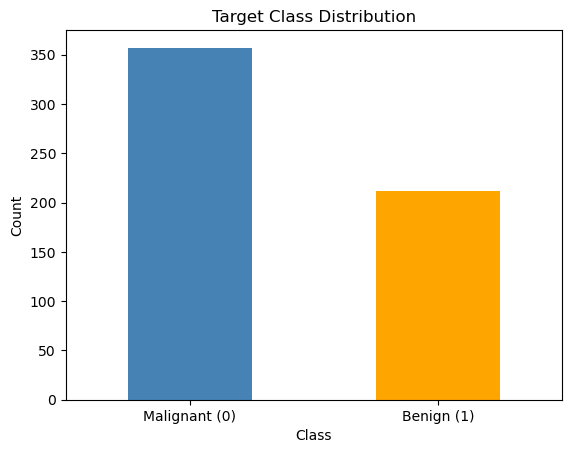

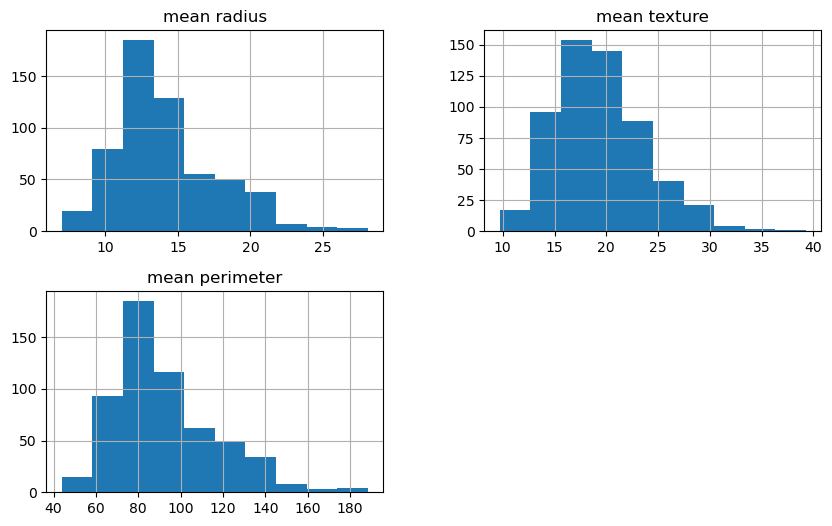

In [16]:
# Step 2
# Create a countplot or bar chart of the target classes
df['target'].value_counts().plot(kind='bar', color=['steelblue', 'orange'])
plt.xticks([0, 1], ['Malignant (0)', 'Benign (1)'], rotation=0)
plt.xlabel('Class')
plt.ylabel('Count')
plt.title('Target Class Distribution')
plt.show()

# Create at least 3 histograms for numeric features of your choice
numeric_features = ['mean radius', 'mean texture', 'mean perimeter']
df[numeric_features].hist(figsize=(10, 6))
plt.show()

the classes are imabalanced

In [11]:
# Step 3
# Set X to the feature columns and y to the target column
X = df.drop(columns=['target'])
y = df['target']

# Split the data into training and test sets using an 80/20 split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Standardize the feature columns using StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [12]:
# Step 4: Balance the training data with SMOTE
# Apply SMOTE(random_state=42) to the scaled training set
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

# Print the class counts before SMOTE
print("Class counts before SMOTE:")
print(y_train.value_counts())

# Print the class counts after SMOTE
print("Class counts after SMOTE:")
print(y_resampled.value_counts())

Class counts before SMOTE:
target
1    285
0    170
Name: count, dtype: int64
Class counts after SMOTE:
target
1    285
0    285
Name: count, dtype: int64


Accuracy: 0.9385964912280702
Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.90      0.92        42
           1       0.95      0.96      0.95        72

    accuracy                           0.94       114
   macro avg       0.94      0.93      0.93       114
weighted avg       0.94      0.94      0.94       114



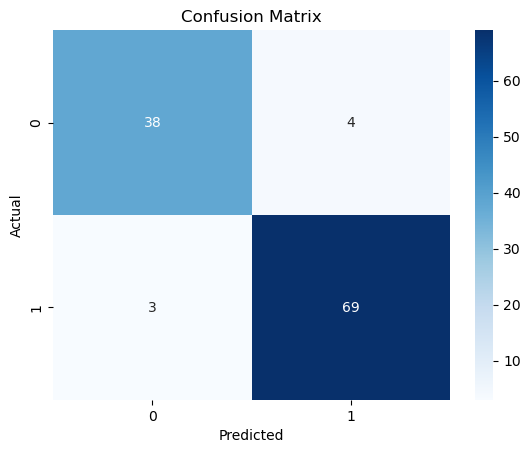

In [13]:
# Step 5: Train and evaluate the model
# Fit the model on the SMOTE-resampled training data
model = GaussianNB()
model.fit(X_resampled, y_resampled)
# Generate predictions on the test set
y_pred = model.predict(X_test)
# Print the accuracy score
print("Accuracy:", accuracy_score(y_test, y_pred))
# Print the classification report
print("Classification Report:\n", classification_report(y_test, y_pred))
# Create and display the confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

The model assumes the majority class is the default and ignores the minority class

SMOTE generates samples that are similar to the minority class balances the training data

Yes. The breast cancer dataset was moderately imbalanced (357 vs 212), and applying SMOTE ensured the model learned equally from both classes. 